Today's topics:
* an objective function and `minimize`
* starting values with `x0`
* reading the result object
* roots as minima of a squared function
* inverting a function

# How thick can a film grow?

Last time we read attributes and called methods on objects other people made.
Today we use a function that returns one.
We pass `minimize` a function, as we did with `curve_fit`.
It calls that function for us.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/b/bd/Molecular-beam_epitaxy_412_RIBER_system_at_LAAS-CNRS.jpg/960px-Molecular-beam_epitaxy_412_RIBER_system_at_LAAS-CNRS.jpg" alt="A molecular-beam epitaxy system, a stainless steel vacuum chamber with many ports, flanges, cooling lines and cables, standing in a cleanroom laboratory" width=480/>

*Photo by QGravelier, [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0), [via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Molecular-beam_epitaxy_412_RIBER_system_at_LAAS-CNRS.jpg).*

Above: A [molecular-beam epitaxy](https://en.wikipedia.org/wiki/Molecular-beam_epitaxy) system at the LAAS-CNRS facility in Toulouse.
Inside the vacuum chamber, heated source cells send beams of atoms toward a wafer.
The atoms build a crystal film on it one layer at a time.

Suppose the film is germanium and the wafer (the **substrate**) is gallium arsenide.
The film copies the crystal of the substrate.
The two lattice constants are not quite equal.
Germanium has $a_f = 5.658$ Å and gallium arsenide has $a_s = 5.653$ Å.
The **lattice mismatch** is

$$f = \frac{a_f - a_s}{a_s}$$

which is $8.8 \times 10^{-4}$ here.

A thin film takes the substrate's in-plane spacing.
We call this **coherent** growth.
The film is strained sideways by the tiny amount $f$.
Every added layer has the same strain, so the elastic energy per unit area grows in proportion to the thickness.

Past some thickness the film can lower its energy by relaxing.
It forms **misfit dislocations**, line defects at the interface.
The energy of the dislocations grows only like the logarithm of the thickness.
The linear curve eventually crosses the logarithmic curve.
That crossover defines the **critical thickness** $d_c$.
Threading dislocations degrade lasers, transistors and solar cells made from the film.

The energy sketch shows the physical competition.
For the numerical example we use a stripped-down Matthews-Blakeslee-type relation.
The original model is a force balance and contains orientation factors that this classroom form omits.

$$d_c = \frac{b}{8 \pi (1 + \nu) f} \ln\left(\frac{\beta d_c}{b}\right)$$

* $b$ is the magnitude of the Burgers vector, the step size of the dislocation. For these crystals $b = a/\sqrt{2} \approx 4$ Å.
* $\nu$ is Poisson's ratio, the sideways contraction when the crystal is stretched. We use 0.28.
* $f$ is the mismatch above.
* $\beta$ is a geometry factor near 1.

The unknown $d_c$ appears alone on the left and also *inside* the logarithm.
No algebraic rearrangement puts $d_c$ alone on one side.
This is a **transcendental** equation.

Move every term to one side to define the gap.

$$\text{gap}(d_c) = d_c - \frac{b}{8 \pi (1 + \nu) f} \ln\left(\frac{\beta d_c}{b}\right)$$

A value of $d_c$ where the gap is zero is a **root** of the function.
Every length here is in Å, since $f$, $\nu$ and $\beta$ have no units.

# An objective function

`minimize` is in `scipy.optimize`, next to `curve_fit`.
Its docstring, from `help(optimize.minimize)`, specifies the required arguments.

> `fun : callable`
> The objective function to be minimized.
> `x0 : ndarray`
> Initial guess.

The **objective function** takes the variable we are adjusting, `x`, and returns one number.
`minimize` calls it with trial values of `x` and keeps the `x` that makes the number smallest.
The initial guess `x0` plays the role `p0` played in `curve_fit`, the first trial value.

Here is a toy objective with its lowest point at $x = 1$.

Text(0, 0.5, 'my_function(x)')

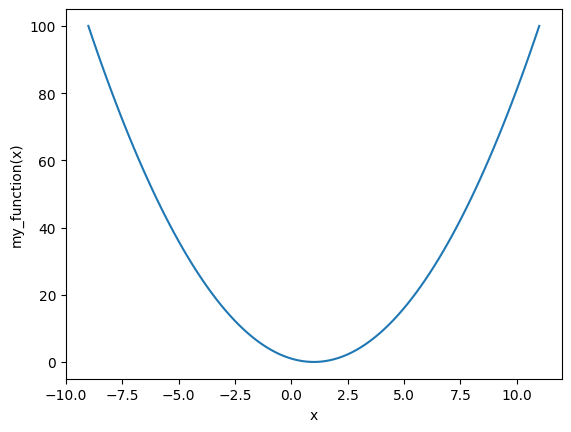

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def my_function(x):
    return (x - 1)**2

x_line = np.linspace(-9, 11, 100)

fig, ax = plt.subplots()
ax.plot(x_line, my_function(x_line))
ax.set_xlabel('x')
ax.set_ylabel('my_function(x)')

We add a `print` to the function so we can watch the calls, as we did with `curve_fit`.
The call to `minimize` has no parentheses after `my_function`.
We pass the function itself, with a starting value of 10.

In [2]:
from scipy import optimize

def my_function(x):
    print(x)
    return (x - 1)**2

res = optimize.minimize(my_function, 10)

[10.]
[10.00000001]
[8.99]
[8.99000001]
[6.82085119]
[6.82085121]
[1.62275063]
[1.62275064]
[0.99999998]
[0.99999999]


The first call uses `x0`, and the later calls move toward the bottom of the parabola.
Calls come in pairs a hair apart, such as 10 and 10.00000001, because `minimize` estimates the slope from a tiny nudge.
Each value printed is an array, because `minimize` always passes the objective an array of parameters, even when there is only one.

In [3]:
def my_function(x):
    return (x - 1)**2

res = optimize.minimize(my_function, 10)
print(type(res))
res

<class 'scipy.optimize._optimize.OptimizeResult'>


  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 4.746511828433913e-16
        x: [ 1.000e+00]
      nit: 4
      jac: [-2.867e-08]
 hess_inv: [[ 5.000e-01]]
     nfev: 10
     njev: 5

`res` is an object, like the `linregress` result in L20.
We read its parts with a dot and no parentheses, so these are attributes.

* `res.x` is the best `x`.
* `res.fun` is the objective at that `x`.
* `res.success` is `True` when the solver reports that it converged.

The rest of the printout is bookkeeping we can ignore for now.

In [4]:
print(res.x)
print(res.fun)
print(res.success)

[0.99999998]
4.746511828433913e-16
True


`res.x` is an array even though there is one parameter.
That is the same array as the printed trial values above.
To use the answer as a plain number, take the first entry.

In [5]:
print(res.x.shape)
print(f'minimum at x = {res.x[0]:.4f}, where the objective is {res.fun:.1e}')

(1,)
minimum at x = 1.0000, where the objective is 4.7e-16


The minimum is at $x = 1$, as the plot showed.
The objective there is not exactly zero but about $5 \times 10^{-16}$, within the solver's stopping precision.

A parameter list works the same way, as `popt` did.
With two parameters, `res.x` has two entries in the order the objective takes its parameters.

### [Check your understanding]

Here is an objective with more than one dip.

```
def wiggle(x):
    return x**4 - 3 * x**2 + x
```

1. Define `wiggle`, then plot it for `x` from -2 to 2 with `np.linspace(-2, 2, 200)`.
   How many dips does the curve have, and which dip is deeper?
2. Call `optimize.minimize(wiggle, -2)` and store the result as `res_left`.
   Call it again with `x0 = 2` and store `res_right`.
   For each, print `res.x[0]`, `res.fun` and `res.success`.
3. Add both points to your plot with `ax.plot(res.x, res.fun, 'o')`.
   Does each point lie in the dip you expected?
4. Try `x0 = 0.1`.
   Which dip contains the returned point?
   Explain in a sentence why a different `x0` can return a different `res.x`, and how that compares with `p0` in `curve_fit`.

# Roots as minima

Back to the critical thickness.
We need the constants and the gap function from the start of class.
The function reads `mismatch` and the other constants from the notebook, as in L18.

In [6]:
b = 4.0           # Burgers vector magnitude, Å
nu = 0.28         # Poisson's ratio
beta = 1.0        # geometry factor
a_film = 5.658    # Ge, Å
a_sub = 5.653     # GaAs, Å

mismatch = (a_film - a_sub) / a_sub
print(f'mismatch = {mismatch:.2e}')

def thickness_gap(dc):
    """gap(dc) in Å, which is zero at the critical thickness.

    dc: thickness in Å (a number or an array)
    Reads b, nu, beta and mismatch from the notebook.
    """
    return dc - b / (8 * np.pi * (1 + nu) * mismatch) * np.log(beta * dc / b)

mismatch = 8.84e-04


Here is the gap over a range of thicknesses.
A root is a place where the curve crosses the dashed zero line.

Text(0, 0.5, 'gap (Å)')

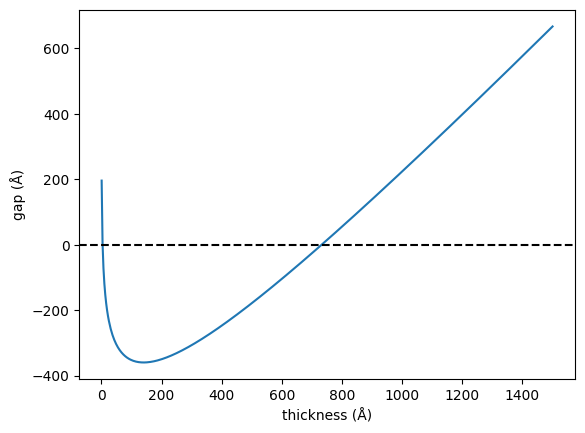

In [7]:
thick = np.linspace(1, 1500, 500)  # Å

fig, ax = plt.subplots()
ax.plot(thick, thickness_gap(thick))
ax.axhline(0, color='black', linestyle='--')
ax.set_xlabel('thickness (Å)')
ax.set_ylabel('gap (Å)')

The curve crosses zero near 730 Å.
Between the two crossings the gap is negative, with its lowest point near 140 Å.
The second crossing is close to the left edge.

We could read 730 off the plot, and `minimize` makes the number precise.
It returns a minimum, though, and the minimum of the gap is not a root.
Let's start at 200 Å and see what it returns.

In [8]:
res = optimize.minimize(thickness_gap, 200)
print(f'minimum at {res.x[0]:.1f} Å, where the gap is {res.fun:.1f} Å')

minimum at 140.6 Å, where the gap is -359.8 Å


The minimum is near 141 Å, where the gap is -360 Å.
A root instead has gap zero.
Squaring makes every value nonnegative and turns each root into a minimum.

Text(0, 0.5, 'gap$^2$ (Å$^2$)')

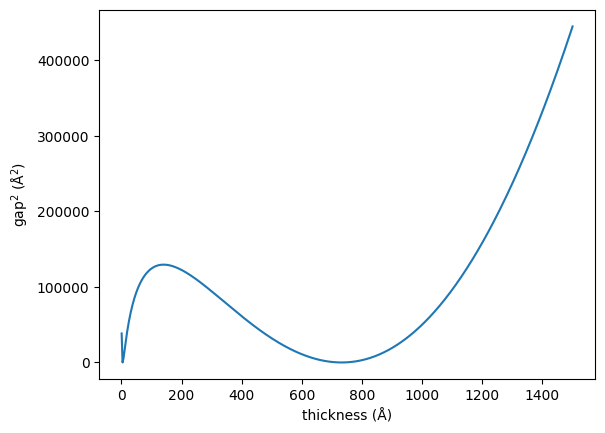

In [9]:
def sq_gap(dc):
    return thickness_gap(dc)**2

fig, ax = plt.subplots()
ax.plot(thick, sq_gap(thick))
ax.set_xlabel('thickness (Å)')
ax.set_ylabel('gap$^2$ (Å$^2$)')

The squared curve touches zero at 730 Å.
It also has a hump near 141 Å, the dip that was a minimum of the gap itself.
Now we start `minimize` on the squared function.

In [10]:
res = optimize.minimize(sq_gap, 800)
print(res.x[0], res.fun, res.success)

732.4234494517297 3.4029710783341577e-17 True


The solver reports a critical thickness of 732.4 Å, which is 73 nm.
The squared gap there is about $3 \times 10^{-17}$ Å².
We can undo the square to check the original equation.

In [11]:
print(thickness_gap(res.x[0]))

-5.833499017171562e-09


The gap is about $-6 \times 10^{-9}$ Å.
The extra digits are a check on the arithmetic.
They do not represent growth precision.

What about the other crossing?
The gap has a second root at small thickness.
A start at 10 Å converges to that root.

In [12]:
res_small = optimize.minimize(sq_gap, 10)
print(res_small.x[0], res_small.fun, res_small.success)

4.118933308895321 5.956845225436593e-14 True


This one is also a perfect root, at 4.12 Å.
It is not a useful answer.
4.12 Å is barely more than one Burgers vector.
The logarithm there is $\ln(4.12/4) = 0.03$, so the dislocation term in the equation has nearly vanished.
A film one or two atoms thick is a poor place to talk about misfit dislocations.

Both runs report `success = True`.
That flag records only that the solver met its stopping test.
Whether that minimum is the answer we need is our call.
We pick `x0` from the physics.
A start near 500 Å lies in the physically relevant range.

The logarithm is defined only for positive thickness.
This unconstrained optimizer may evaluate zero or negative values from some starts, producing a `RuntimeWarning` or a failed result.
We therefore choose a positive start in the physically relevant range and still check `res.success`.

# Inverting a function

A root is the special case of asking where a function equals zero.
The general case is to find where it equals any value $y_0$.
Subtract $y_0$ to make the question a root, then square.
The objective is

$$[f(x) - y_0]^2$$

L19 fitted a model of the compression test, force against position.
That model runs forward, from position to force.
A test engineer often needs it backward.
How far does the platen have to travel to load the part to 2000 lb?

Here is the fitted two-term model from L19, with its three fitted values typed in.
The test ran from 0 to 0.465 in.

Text(0, 0.5, 'force (lb)')

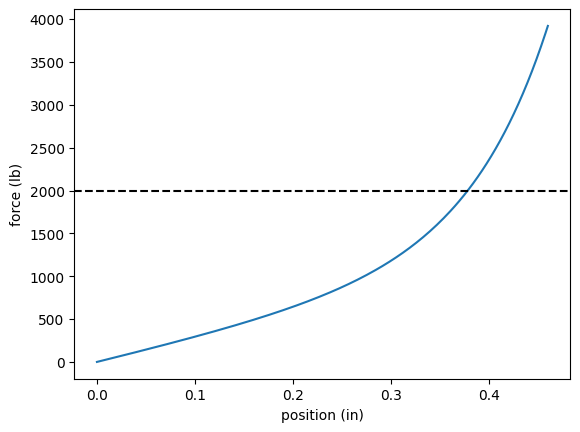

In [13]:
def force_model(x):
    """Force in lb at position x in inches, from the L19 two-term fit."""
    return 2717.64 * x + 9.3865 * (np.exp(12.2916 * x) - 1)

target = 2000  # lb

x_fit = np.linspace(0, 0.46, 200)

fig, ax = plt.subplots()
ax.plot(x_fit, force_model(x_fit), '-')
ax.axhline(target, color='black', linestyle='--')
ax.set_xlabel('position (in)')
ax.set_ylabel('force (lb)')

The position we need is where the fitted curve meets the dashed line.
The objective is the squared difference, divided by the target to make it a fractional miss.
The raw squared difference is in lb² and runs to millions.
With it, `minimize` reported `success = False` for this target.
After dividing by the target, the objective has no units and stays near 1 or below, and the run reports `success = True`.

The function reads `target` from the notebook when it is called.
Changing `target` changes the objective without editing the function.

In [14]:
def miss(x):
    return ((force_model(x) - target) / target)**2

res = optimize.minimize(miss, 0.2)
print(res.x[0], res.fun, res.success)

0.3782798625084099 2.2500184330163135e-15 True


The platen has to travel 0.378 in.
We check by running the model forward at that position.

1999.9999051312816


Text(0, 0.5, 'force (lb)')

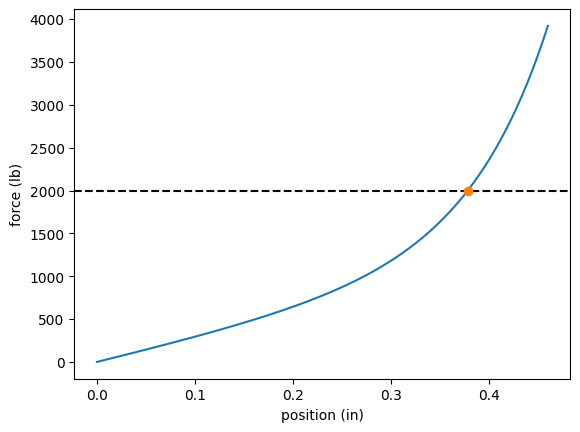

In [15]:
print(force_model(res.x[0]))

fig, ax = plt.subplots()
ax.plot(x_fit, force_model(x_fit), '-')
ax.axhline(target, color='black', linestyle='--')
ax.plot(res.x, force_model(res.x), 'o')
ax.set_xlabel('position (in)')
ax.set_ylabel('force (lb)')

The forward model returns 2000 lb at 0.378 in.
The starting value of 0.2 in is a spot between zero and the end of the test, read from the plot.
This is a prediction from the fitted curve.
It is only as good as the fit in that range.

### [Check your understanding]

Use the same `miss` function, the same `force_model` and the same `target` name.

1. Set `target = 3500` on its own line, and do not edit `miss`.
   Call `optimize.minimize(miss, 0.2)` and print `res.x[0]` and `res.success`.
   Why does the new target take effect without editing `miss`?
2. Print `force_model(res.x[0])` and check that it is close to 3500.
   Optional: add the point to a plot of the fitted curve and the dashed target line.
3. Write a second objective, `miss_raw(x)`, that returns `force_model(x) - target` with no square and no division.
   Print `miss_raw(0.1)` and `miss_raw(0.4)`.
   If we passed `miss_raw` to `minimize`, would the best `x` be the one where the model force is 3500 lb?
   Explain in a sentence.

# Summary

* An objective function takes the variable being adjusted and returns one number.
  `minimize(objective, x0)` calls it many times.
  We pass the function without parentheses.
* `x0` is the first trial value, like `p0` in `curve_fit`.
  Different starting values can converge to different minima.
* `minimize` returns an object.
  `res.x` holds the best parameters as an array, even for one parameter, so we use `res.x[0]` for a number.
  `res.fun` is the objective at that point.
  `res.success` reports convergence.
* A root of $g(x)$ is a minimum of $g(x)^2$.
  Minimizing $g$ itself returns its lowest point.
  That point is generally not a root.
* To find where $f(x)$ equals $y_0$, minimize $[f(x) - y_0]^2$.
* `success = True` means the solver met its stopping test.
  Whether that minimum is the answer we need is our call.
  The same squared gap has roots at 4.1 Å and 732 Å, so `x0` has to come from the physical problem.
* The critical thickness of germanium on gallium arsenide is about 730 Å in this simplified model.

## Further reading

* [`scipy.optimize.minimize` documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html)
* Matthews and Blakeslee, "Defects in epitaxial multilayers I: misfit dislocations," *Journal of Crystal Growth* 27 (1974) 118-125, for the force-balance model behind the relation we used
* People and Bean, "Calculation of critical layer thickness versus lattice mismatch for GexSi1-x/Si strained-layer heterostructures," *Applied Physics Letters* 47 (1985) 322-324, [DOI 10.1063/1.96206](https://doi.org/10.1063/1.96206), for the energy-balance picture
* Photo credit: molecular-beam epitaxy system, QGravelier, [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0), [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Molecular-beam_epitaxy_412_RIBER_system_at_LAAS-CNRS.jpg)

# Appendix A: Counting function calls

Optional.
We could also solve the thickness problem by brute force.
Evaluate the squared gap on a grid and take the smallest value.
`res.nfev` counts how many times `minimize` called the objective.

In [16]:
mismatch = (a_film - a_sub) / a_sub  # Ge on GaAs

res = optimize.minimize(sq_gap, 500)
print(f'minimize: {res.nfev} calls, squared gap {res.fun:.1e}')

for n in [10, 100, 10000]:
    grid = np.linspace(1, 1500, n)
    print(f'{n} grid points: smallest squared gap {np.min(sq_gap(grid)):.1e}')

minimize: 20 calls, squared gap 7.5e-17
10 grid points: smallest squared gap 2.7e+03
100 grid points: smallest squared gap 1.4e+01
10000 grid points: smallest squared gap 9.1e-05


`minimize` ends with a far smaller squared gap in about twenty calls than a grid of 10,000 points.
A grid with 100 points per direction needs $100^2$ calls for two parameters and $100^{10}$ for ten.

# Appendix B: What else is in the result

Optional.
The printout of `res` showed more attributes than `x`, `fun` and `success`.
Three more are useful.

In [17]:
mismatch = (a_film - a_sub) / a_sub  # Ge on GaAs

res = optimize.minimize(sq_gap, 500)
print(res.message)
print(res.nit)
print(res.nfev)

Optimization terminated successfully.
6
20


* `message` says in words why the solver stopped.
* `nit` counts the solver's iterations.
* `nfev` counts the calls to the objective, including the extra calls used to estimate slopes.

`nfev` is larger than `nit` because each iteration calls the objective more than once.

# Appendix C: A design curve

Optional.
The critical thickness belongs to one substrate and one film.
Growers adjust the lattice constant of the film by alloying, which changes the mismatch.
A loop evaluates the critical thickness for several mismatch values.

Inside the loop, `mismatch` is set before each call.
`thickness_gap` reads that name when `minimize` runs it.

In [18]:
mismatch_list = [0.0005, 0.001, 0.002, 0.004]
critical = []

for mismatch in mismatch_list:
    res = optimize.minimize(sq_gap, 500)
    critical.append(res.x[0])
    print(f'mismatch {mismatch:.4f}: critical thickness {res.x[0]:.0f} Å, success = {res.success}')

mismatch = (a_film - a_sub) / a_sub  # restore Ge on GaAs

mismatch 0.0005: critical thickness 1469 Å, success = True
mismatch 0.0010: critical thickness 629 Å, success = True
mismatch 0.0020: critical thickness 259 Å, success = True
mismatch 0.0040: critical thickness 100 Å, success = True


Doubling the mismatch divides the critical thickness by a factor between 2.3 and 2.6.
A mismatch of 0.4% leaves about 100 Å, or 10 nm, of coherent film.
That is far thinner than the micrometer-scale absorber layer of many solar cells.
Germanium on gallium arsenide, at a mismatch of 0.09%, allows about 730 Å.

Text(0, 0.5, 'critical thickness (Å)')

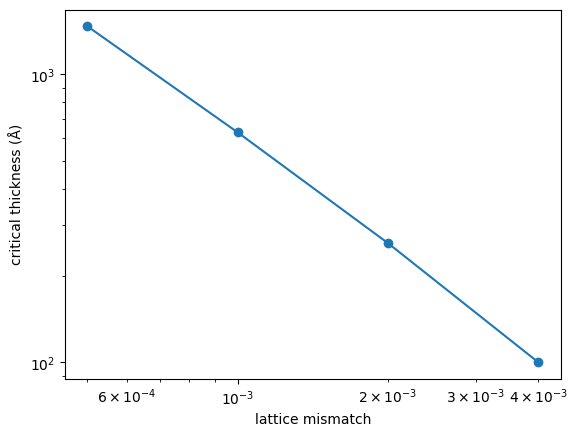

In [19]:
fig, ax = plt.subplots()
ax.plot(mismatch_list, critical, 'o-')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('lattice mismatch')
ax.set_ylabel('critical thickness (Å)')

On log axes the slope between neighboring points is between -1.2 and -1.4.
A pure $1/f$ dependence has slope -1.
The logarithm in the equation steepens it.